In [1]:
# Run this cell to set up packages for lecture.
from lec16_imports import *

# Lecture 16 – Standardization and the Normal Distribution

## DSC 10, Spring 2026

### Agenda

- Chebyshev's inequality.
- Standardization.
- The normal distribution.

## Chebyshev's inequality

### Recap: variance and standard deviation

$$\begin{align*}\text{variance} &= \text{average squared deviation from the mean}\\
&= \frac{(\text{value}_1 - \text{mean})^2 + ... + (\text{value}_n - \text{mean})^2}{n}\\
\text{standard deviation} &= \sqrt{\text{variance}}
\end{align*}$$

where $n$ is the number of observations.

### Standard deviation

- The standard deviation (SD) measures something about how far the data values are from their average.
    - It is not directly interpretable because of the squaring and square rooting.
    - But generally, **larger SD = more spread out**.

- The standard deviation has the same units as the original data.

- `numpy` has a function, `np.std`, that calculates the standard deviation for us.

In [2]:
np.std([2, 3, 3, 9])

2.7726341266023544

### What can we do with the standard deviation?

It turns out, in **any** numerical distribution, the bulk of the data are in the range “mean ± a few SDs”.

Let's make this more precise.

### Chebyshev’s inequality

**Fact**: In **any** numerical distribution, the proportion of values in the range “mean ± $z$ SDs” is at least 

$$1 - \frac{1}{z^2}
$$

|Range|Proportion|
|---|---|
|mean ± 2 SDs|	at least $1 - \frac{1}{4}$   (75%)|
|mean ± 3 SDs|	at least $1 - \frac{1}{9}$   (88.88..%)|
|mean ± 4 SDs|	at least $1 - \frac{1}{16}$ (93.75%)|
|mean ± 5 SDs|	at least $1 - \frac{1}{25}$  (96%)|


### Flight delays, revisited ✈️

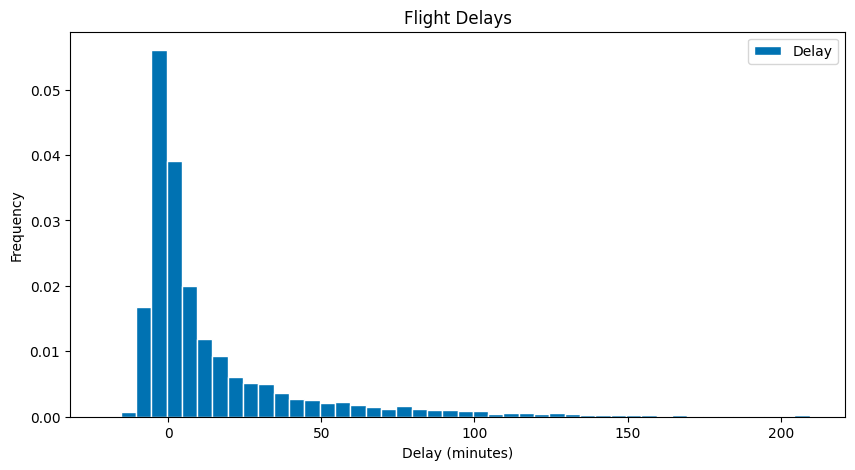

In [3]:
delays = bpd.read_csv('data/united_summer2015.csv')
delays.plot(kind='hist', y='Delay', bins=np.arange(-20.5, 210, 5), density=True, ec='w', figsize=(10, 5), title='Flight Delays')
plt.xlabel('Delay (minutes)');

In [4]:
delay_mean = delays.get('Delay').mean()
delay_mean

16.658155515370705

In [5]:
delay_std = np.std(delays.get('Delay')) # There is no .std() method in babypandas!
delay_std

39.480199851609314

### Mean and standard deviation

Chebyshev's inequality tells us that

- **At least** 75% of delays are in the following interval:

In [6]:
delay_mean - 2 * delay_std, delay_mean + 2 * delay_std

(-62.30224418784792, 95.61855521858934)

- **At least** 88.88% of delays are in the following interval:

In [7]:
delay_mean - 3 * delay_std, delay_mean + 3 * delay_std

(-101.78244403945723, 135.09875507019865)

Let's visualize these intervals!

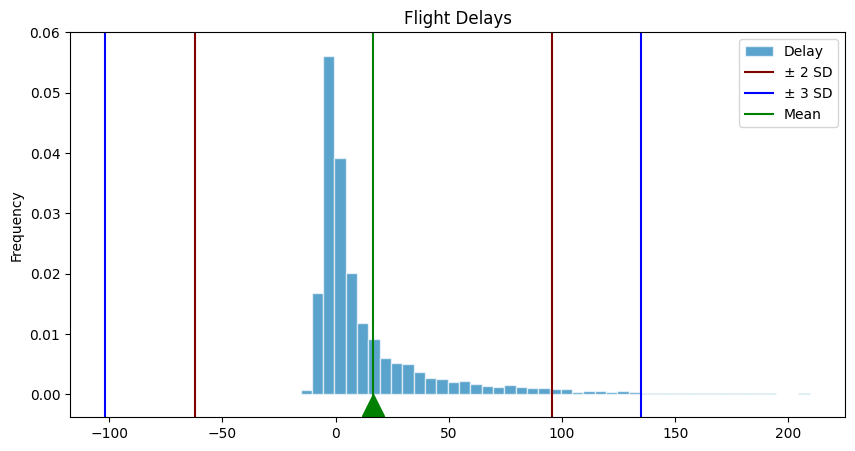

In [8]:
delays.plot(kind='hist', y='Delay', bins=np.arange(-20.5, 210, 5), density=True, alpha=0.65, ec='w', figsize=(10, 5), title='Flight Delays')
plt.axvline(delay_mean - 2 * delay_std, color='maroon', label='± 2 SD')
plt.axvline(delay_mean + 2 * delay_std, color='maroon')

plt.axvline(delay_mean + 3 * delay_std, color='blue',  label='± 3 SD')
plt.axvline(delay_mean - 3 * delay_std, color='blue')

plt.axvline(delay_mean, color='green', label='Mean')
plt.scatter([delay_mean], [-0.0017], color='green', marker='^', s=250)
plt.ylim(-0.0038, 0.06)
plt.legend();

### Chebyshev's inequality provides _lower_ bounds!

Remember, Chebyshev's inequality states that **at least** $1 - \frac{1}{z^2}$ of values are within $z$ SDs from the mean, for any numerical distribution.

For instance, it tells us that **at least** 75% of delays are in the following interval:

In [9]:
delay_mean - 2 * delay_std, delay_mean + 2 * delay_std

(-62.30224418784792, 95.61855521858934)

However, in this case, a much larger fraction of delays are in that interval.

In [10]:
within_2_sds = delays[(delays.get('Delay') >= delay_mean - 2 * delay_std) & 
                      (delays.get('Delay') <= delay_mean + 2 * delay_std)]

within_2_sds.shape[0] / delays.shape[0]

0.9560940325497288

If we know more about the shape of the distribution, we can provide better guarantees for the proportion of values within $z$ SDs of the mean.

### Activity

For a particular set of data points, Chebyshev's inequality states that at least $\frac{8}{9}$ of the data points are between $-20$ and $40$. What is the standard deviation of the data?


<details><summary>✅ Click here to see the answer <b>after</b> you've tried it yourself.</summary>

- Chebyshev's inequality states that at least $1 - \frac{1}{z^2}$ of values are within $z$ standard deviations of the mean.
- When $z = 3$, $1 - \frac{1}{z^2} = \frac{8}{9}$.
- So, $-20$ is $3$ standard deviations below the mean, and $40$ is $3$ standard deviations above the mean.
- $10$ is in the middle of $-20$ and $40$, so the mean is $10$.
- $3$ standard deviations are between $10$ and $40$, so $1$ standard deviation is $\frac{30}{3} = 10$.
</details>

## Standardization

### Heights and weights 📏

We'll work with a data set containing the heights and weights of 5000 adult males. 

In [11]:
height_and_weight = bpd.read_csv('data/height_and_weight.csv')
height_and_weight

,Height,Weight
0,73.85,241.89
1,68.78,162.31
2,74.11,212.74
...,...,...
4997,67.01,199.20
4998,71.56,185.91
4999,70.35,198.90


### Distributions of height and weight

Let's look at the distributions of both numerical variables.

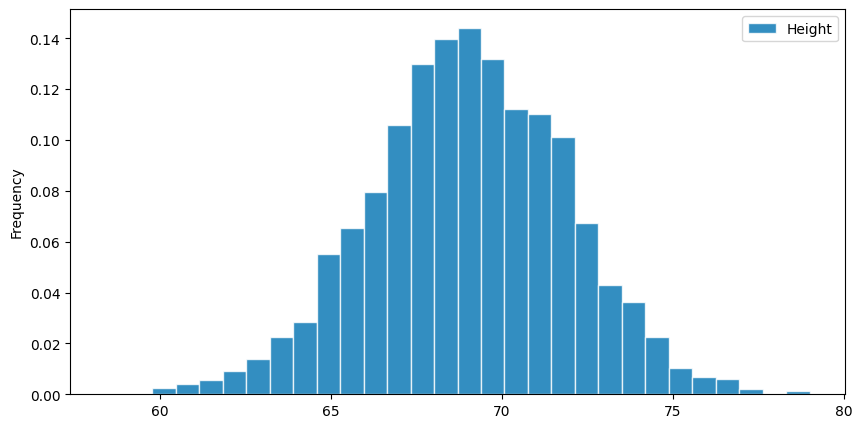

In [12]:
height_and_weight.plot(kind='hist', y='Height', density=True, ec='w', bins=30, alpha=0.8, figsize=(10, 5));

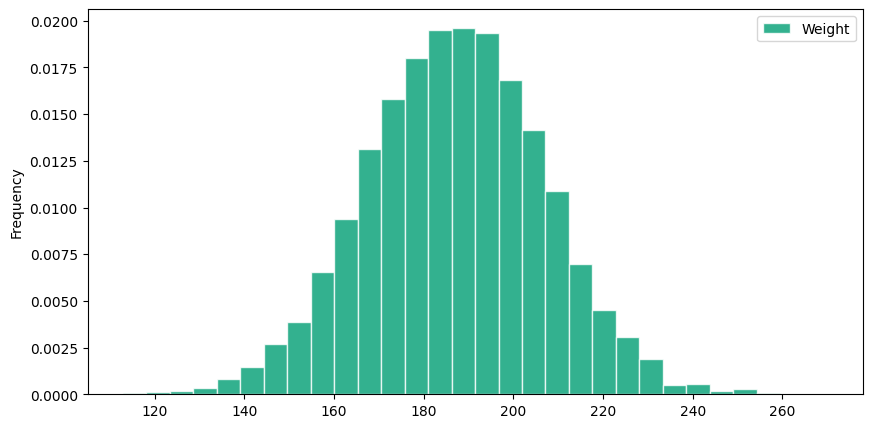

In [13]:
height_and_weight.plot(kind='hist', y='Weight', density=True, ec='w', bins=30, alpha=0.8, color='C1', figsize=(10, 5));

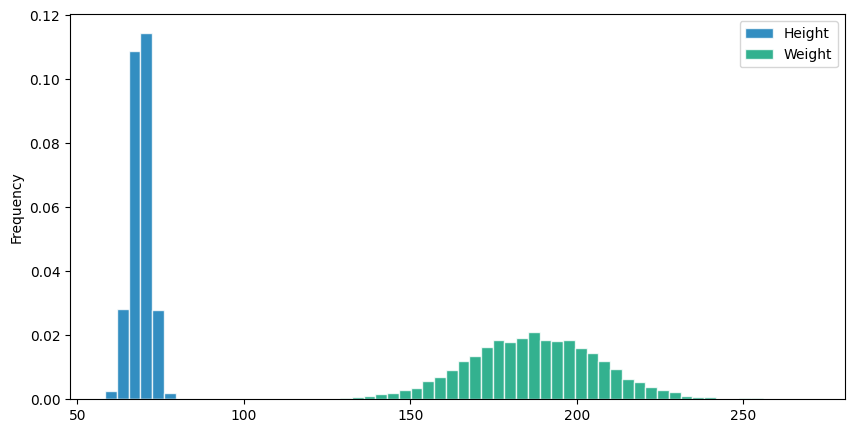

In [14]:
height_and_weight.plot(kind='hist', density=True, ec='w', bins=60, alpha=0.8, figsize=(10, 5));

**Observation**: The two distributions look like shifted and stretched versions of the same basic shape, called a **bell curve** 🔔. Distributions shaped like this are called **normal distributions**.

### Many normal distributions

- There are many normal distributions, with different means and different standard deviations. 

- All normal distributions are shaped like bell curves, but they vary in center and spread.

- The mean and standard deviation uniquely define a normal distribution. There is only one normal distribution with a given mean and SD.

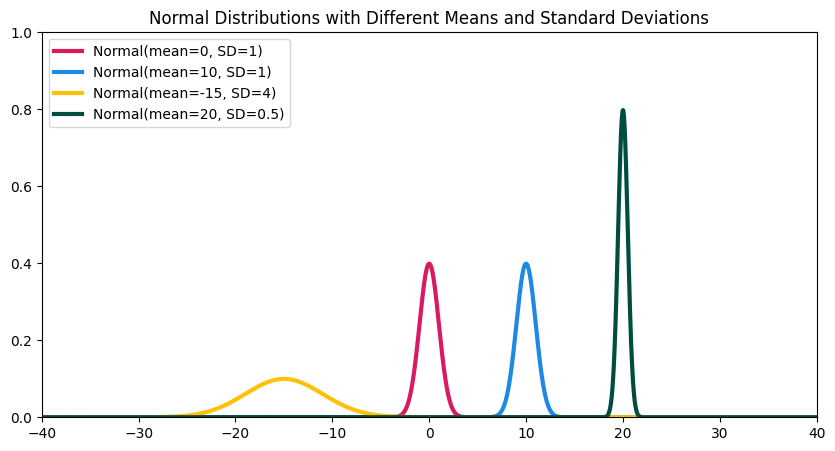

In [15]:
show_many_normal_distributions()

- Note that the area underneath each curve is 1. Therefore, the taller curves are narrower, and the shorter curves are wider.

- Any normal distribution can be shifted and scaled to look like any other normal distribution. Let's see how with height and weight!

### Standard units

Suppose $x$ is a numerical variable, and $x_i$ is one value of that variable. Then, $$x_{i \: \text{(su)}} = \frac{x_i - \text{mean of $x$}}{\text{SD of $x$}}$$

represents $x_i$ in **standard units** – the number of standard deviations $x_i$ is above the mean.

**Example**: Suppose someone weighs 225 pounds. What is their weight in standard units?

In [16]:
weights = height_and_weight.get('Weight')
(225 - weights.mean()) / np.std(weights)

1.9201699181580782

- Interpretation: 225 is 1.92 standard deviations above the mean weight.
- 225 becomes 1.92 in **standard units**.

### Standardization

The process of converting all values of a variable (i.e. a column) to standard units is known as standardization, and the resulting values are considered to be **standardized**.

In [17]:
def standard_units(col):
    return (col - col.mean()) / np.std(col)

In [18]:
standardized_height = standard_units(height_and_weight.get('Height'))
standardized_height

0       1.68
1      -0.09
2       1.78
        ... 
4997   -0.70
4998    0.88
4999    0.46
Name: Height, Length: 5000, dtype: float64

In [19]:
standardized_weight = standard_units(height_and_weight.get('Weight'))
standardized_weight

0       2.77
1      -1.25
2       1.30
        ... 
4997    0.62
4998   -0.06
4999    0.60
Name: Weight, Length: 5000, dtype: float64

### The effect of standardization

Standardized variables have:
- A mean of 0.
- An SD of 1.

We often standardize variables to bring them to the same scale.

In [20]:
# e-15 means 10^(-15), which is a very small number, effectively zero.
standardized_height.describe()

count    5.00e+03
mean     1.49e-15
std      1.00e+00
           ...   
50%      4.76e-04
75%      6.85e-01
max      3.48e+00
Name: Height, Length: 8, dtype: float64

In [21]:
standardized_weight.describe()

count    5.00e+03
mean     5.96e-16
std      1.00e+00
           ...   
50%      6.53e-04
75%      6.74e-01
max      4.19e+00
Name: Weight, Length: 8, dtype: float64

Let's look at how the process of standardization works visually.

In [22]:
HTML('data/height_anim.html')

In [23]:
HTML('data/weight_anim.html')

### Standardized histograms

Now that we've standardized the distributions of height and weight, let's see how they look on the same set of axes.

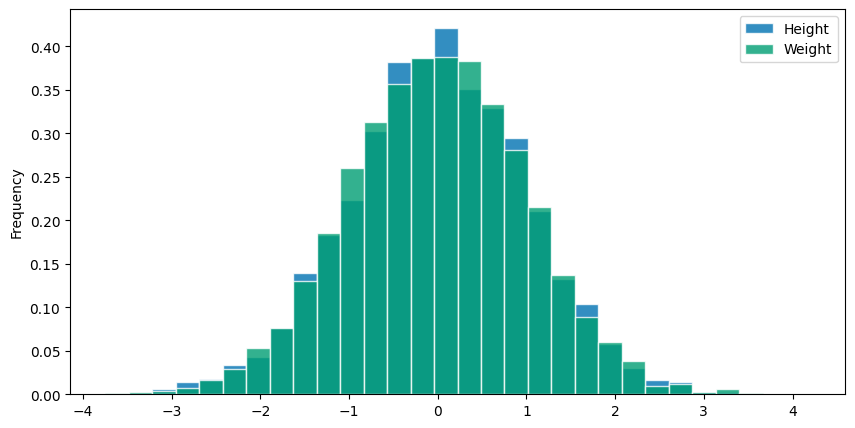

In [24]:
standardized_height_and_weight = bpd.DataFrame().assign(
    Height=standardized_height,
    Weight=standardized_weight
)
standardized_height_and_weight.plot(kind='hist', density=True, ec='w',bins=30, alpha=0.8, figsize=(10, 5));

These both look very similar!

## The standard normal distribution

### The standard normal distribution

- The distributions we've seen look essentially the same once standardized.
- This distribution is called the **standard normal distribution**. It is defined by its mean of 0 and its standard deviation of 1. The shape of such a distribution is called the **standard normal curve**.

$$
\phi(z) = \frac{1}{\sqrt{2 \pi}} e^{-\frac{1}{2}z^2}
$$


- You don't need to know the formula – just the shape!
    - We'll just use the formula today to make plots.

### The standard normal curve

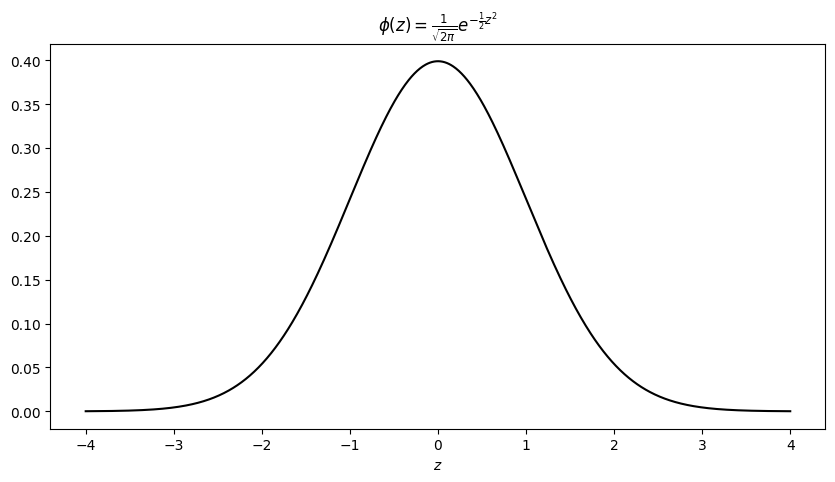

In [25]:
def normal_curve(z):
    return 1 / np.sqrt(2 * np.pi) * np.exp((-z**2)/2)

x = np.linspace(-4, 4, 1000)
y = normal_curve(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='black');
plt.xlabel('$z$');
plt.title(r'$\phi(z) = \frac{1}{\sqrt{2 \pi}} e^{-\frac{1}{2}z^2}$');

### Heights/weights are roughly normal

If a distribution follows this shape, we say it is roughly normal.

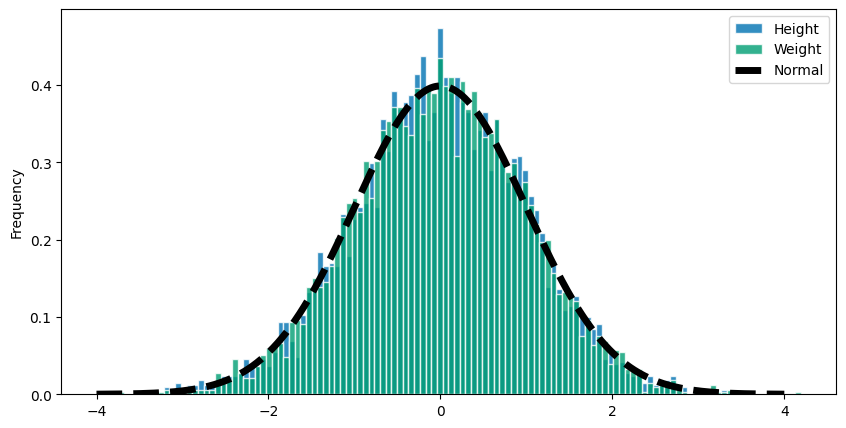

In [26]:
standardized_height_and_weight.plot(kind='hist', density=True, ec='w', bins=120, alpha=0.8, figsize=(10, 5));
plt.plot(x, y, color='black', linestyle='--', label='Normal', linewidth=5)
plt.legend(loc='upper right');

### The standard normal distribution

- Think of the normal distribution as a "continuous histogram".

- Its mean and median are both 0 – it is symmetric.

- It has inflection points at $\pm 1$.
    - More on this later.

- Like a histogram:
    - The **area** between $a$ and $b$ is the **proportion** of values between $a$ and $b$.
    - The total area underneath the normal curve is is 1.

In [27]:
sliders()

Output()

### Cumulative density functions

- The _cumulative density function_ (CDF) of a distribution is a function that takes in a value $z$ and returns the proportion of values in the distribution that are less than or equal to $z$, i.e. **the area under the curve to the left of $z$**.

- To find areas under curves, we typically use integration (calculus). However, the standard normal curve has no closed-form integral.

- Often, people refer to [tables](https://www.math.arizona.edu/~jwatkins/normal-table.pdf) that contain approximations of the CDF of the standard normal distribution.

- We'll use an approximation built into the `scipy` module in Python. The function `scipy.stats.norm.cdf(z)` computes the **area under the standard normal curve to the left of `z`**.

### Areas under the standard normal curve

What does `scipy.stats.norm.cdf(0)` evaluate to? Why?

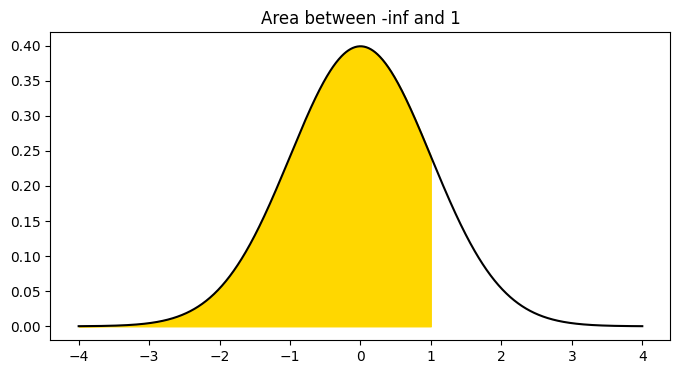

In [28]:
normal_area(-np.inf, 1)

In [29]:
from scipy import stats
stats.norm.cdf(1)

0.8413447460685429

### Areas under the standard normal curve

Suppose we want to find the area to the **right** of 2 under the standard normal curve.

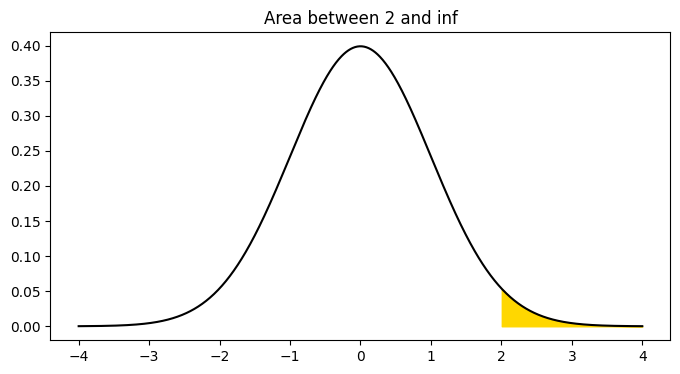

In [30]:
normal_area(2, np.inf)

The following expression gives us the area to the **left** of 2.

In [31]:
stats.norm.cdf(2)

0.9772498680518208

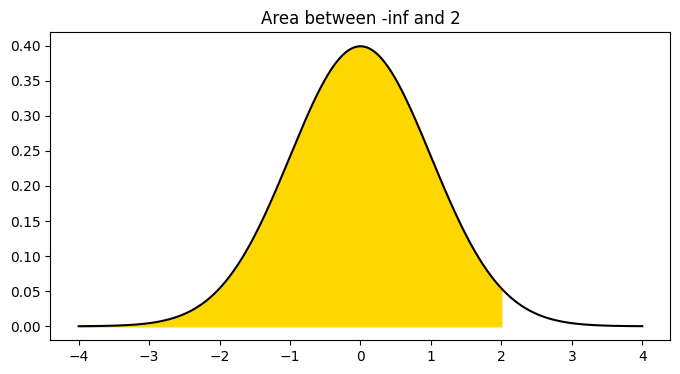

In [32]:
normal_area(-np.inf, 2)

However, since the total area under the standard normal curve is 1:

$$\text{area right of $2$} = 1 - (\text{area left of $2$})$$

In [33]:
1 - stats.norm.cdf(2)

0.02275013194817921

### Areas under the standard normal curve

How might we use `stats.norm.cdf` to compute the area between -1 and 0?

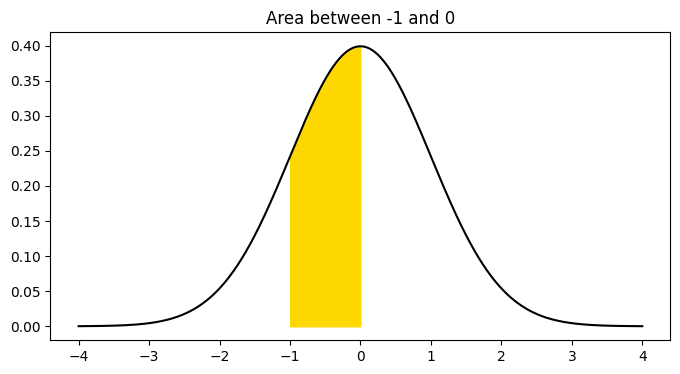

In [34]:
normal_area(-1, 0)

Strategy:

$$\text{area from $-1$ to $0$} = (\text{area left of $0$}) - (\text{area left of $-1$})$$

In [35]:
stats.norm.cdf(0) - stats.norm.cdf(-1)

0.3413447460685429

### General strategy for finding area

The area under a standard normal curve in the interval $[a, b]$ is 

```py
stats.norm.cdf(b) - stats.norm.cdf(a)
```

What can we do with this? We're about to see!

### Using the normal distribution

Let's return to our data set of heights and weights.

In [36]:
height_and_weight

,Height,Weight
0,73.85,241.89
1,68.78,162.31
2,74.11,212.74
...,...,...
4997,67.01,199.20
4998,71.56,185.91
4999,70.35,198.90


As we saw before, both variables are roughly normal. What _benefit_ is there to knowing that the two distributions are roughly normal?

### Standard units and the normal distribution

- **Key idea: The $x$-axis in a plot of the <u>standard</u> normal distribution is in <u>standard</u> units.**
    - For instance, the area between -1 and 1 is the proportion of values within 1 standard deviation of the mean.

- Suppose a distribution is (roughly) normal. Then, these are two are approximately equal:
    - The proportion of values in the distribution between $a$ and $b$.
    - The area between $a_{\: \text{(su)}}$ and $b_{\: \text{(su)}}$ under the standard normal curve.
        - Recall, $x_{i \: \text{(su)}} = \frac{x_i - \text{mean of $x$}}{\text{SD of $x$}}$.

### Example: Proportion of weights between 200 and 225 pounds

Let's suppose, as is often the case, that we don't have access to the entire distribution of weights, but just the mean and SD.

In [37]:
weight_mean = weights.mean()
weight_mean

187.0206206581932

In [38]:
weight_std = np.std(weights)
weight_std

19.779176302396458

Using just this information, we can estimate the proportion of weights between 200 and 225 pounds:

1. Convert 200 to standard units.
2. Convert 225 to standard units.
3. Use `stats.norm.cdf` to find the area between (1) and (2).

In [39]:
left = (200 - weight_mean) / weight_std
left

0.656214351061435

In [40]:
right = (225 - weight_mean) / weight_std
right

1.9201699181580782

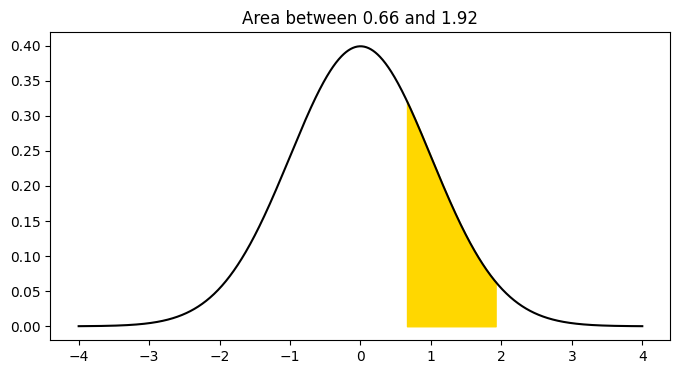

In [41]:
normal_area(left, right)

In [42]:
approximation = stats.norm.cdf(right) - stats.norm.cdf(left)
approximation

0.22842488819306406

### Checking the approximation

Since we have access to the entire set of weights, we can compute the true proportion of weights between 200 and 225 pounds.

In [43]:
# True proportion of values between 200 and 225.
height_and_weight[
    (height_and_weight.get('Weight') >= 200) &
    (height_and_weight.get('Weight') <= 225)
].shape[0] / height_and_weight.shape[0]

0.2294

In [44]:
# Approximation using the standard normal curve.
approximation

0.22842488819306406

Pretty good for an approximation! 🤩

### Warning: Standardization doesn't make a distribution normal!

Consider the distribution of delays from earlier in the lecture.

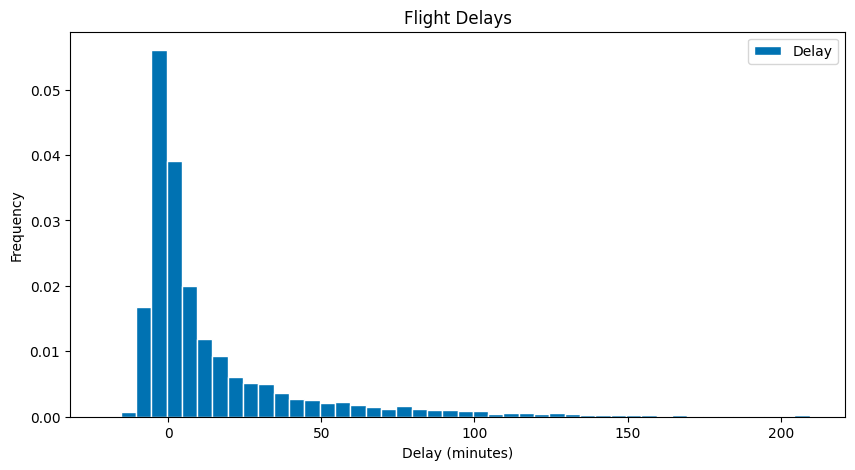

In [45]:
delays.plot(kind='hist', y='Delay', bins=np.arange(-20.5, 210, 5), density=True, ec='w', figsize=(10, 5), title='Flight Delays')
plt.xlabel('Delay (minutes)');

The distribution above does not look normal. It won't look normal even if we standardize it. By standardizing a distribution, all we do is move it horizontally and stretch it vertically – the shape itself doesn't change.

In [46]:
HTML('data/delay_anim.html')

### Chebyshev's inequality and the normal distribution

- Recall that Chebyshev's inequality states that the proportion of values within $z$ SDs of the mean is **at least** $1-\frac{1}{z^2}$.
    - This works for **any** distribution, and is a lower bound.

- If we know that the distribution is normal, we can be even more specific!

| Range | All Distributions (via Chebyshev's inequality) | Normal Distribution|
|---|---|---|
| mean $\pm \ 1$ SD | $\geq 0\%$ |$\approx 68\%$ |
| mean $\pm \ 2$ SDs | $\geq 75\%$ | $\approx 95\%$ |
| mean $\pm \ 3$ SDs | $\geq 88.8\%$ | $\approx 99.73\%$ |

### 68% of values are within 1 SD of the mean

Remember, the values on the $x$-axis for the standard normal curve are in standard units. So, the proportion of values within 1 SD of the mean is the area under the standard normal curve between -1 and 1.

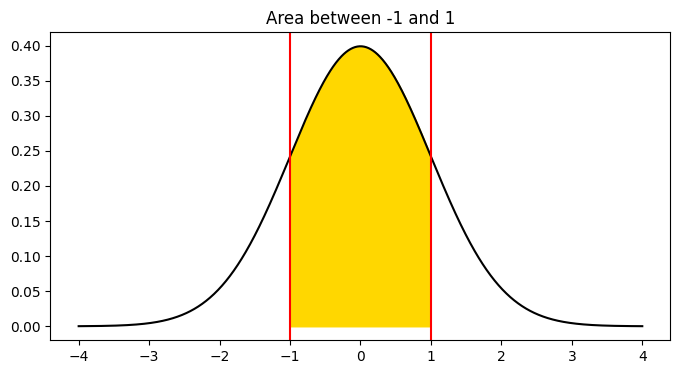

In [47]:
normal_area(-1, 1, bars=True)

In [48]:
stats.norm.cdf(1) - stats.norm.cdf(-1)

0.6826894921370859

This means that if a variable follows a normal distribution, approximately 68% of values will be within 1 SD of the mean.

### 95% of values are within 2 SDs of the mean

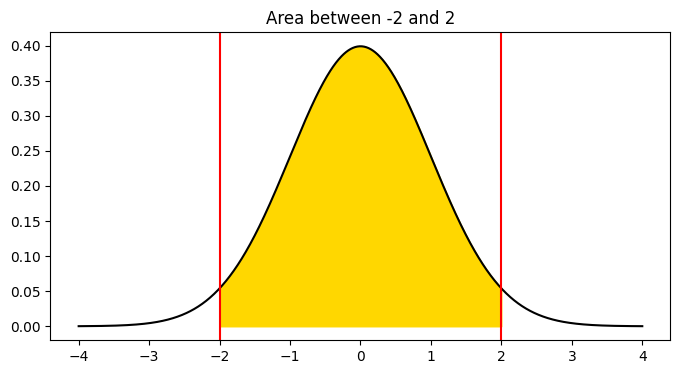

In [49]:
normal_area(-2, 2, bars=True)

In [50]:
stats.norm.cdf(1.96) - stats.norm.cdf(-1.96)

0.950004209703559

- If a variable follows a normal distribution, approximately 95% of values will be within 2 SDs of the mean.
- Consequently, 5% of values will be outside this range.
- Since the normal curve is symmetric, 
    - 2.5% of values will be more than 2 SDs above the mean, and
    - 2.5% of values will be more than 2 SDs below the mean.

### Recap: Proportion of values within $z$ SDs of the mean

| Range | All Distributions (via Chebyshev's inequality) | Normal Distribution|
|---|---|---|
| mean $\pm \ 1$ SD | $\geq 0\%$ |$\approx 68\%$ |
| mean $\pm \ 2$ SDs | $\geq 75\%$ | $\approx 95\%$ |
| mean $\pm \ 3$ SDs | $\geq 88.8\%$ | $\approx 99.73\%$ |

The percentages you see for normal distributions above are approximate, but are not lower bounds.

**Important**: They apply to all normal distributions, standardized or not. This is because all normal distributions are just stretched and shifted versions of the standard normal distribution.

### Inflection points

- We mentioned that the standard normal curve has inflection points at $z = \pm 1$.
    - An inflection point is where a curve goes from "opening down" 🙁 to "opening up" 🙂.

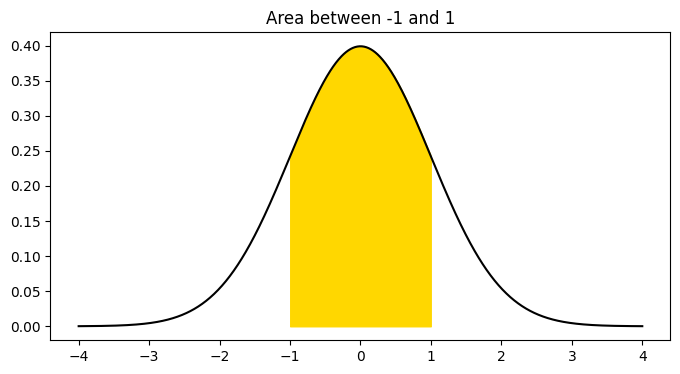

In [51]:
normal_area(-1, 1)

- We know that the $x$-axis of the standard normal curve represents standard units, so the inflection points are at 1 standard deviation above and below the mean.

- This means that if a distribution is roughly normal, we can determine its standard deviation by finding the distance between each inflection point and the mean.

### Example: Inflection points

Remember: The distribution of heights is roughly normal, but it is _not_ a _standard_ normal distribution. 

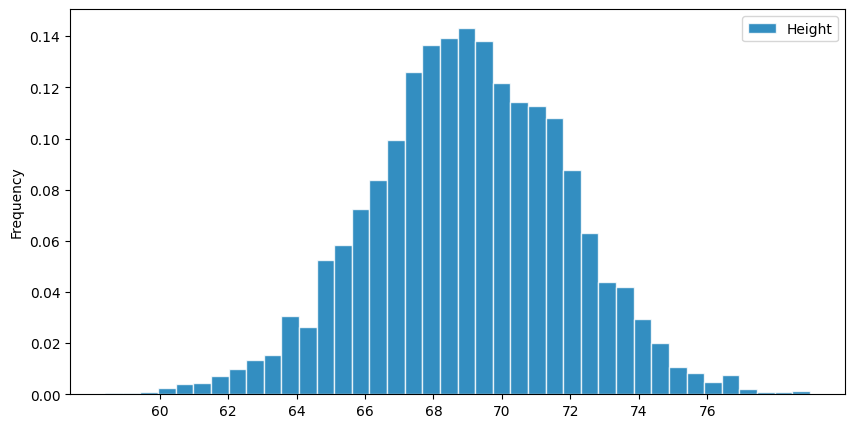

In [52]:
height_and_weight.plot(kind='hist', y='Height', density=True, ec='w', bins=40, alpha=0.8, figsize=(10, 5));
plt.xticks(np.arange(60, 78, 2));

- The center appears to be around 69.
- The inflection points appear to be around 66 and 72.
- So, the standard deviation is roughly 72 - 69 = 3.

In [53]:
np.std(height_and_weight.get('Height'))

2.863075878119538

## Summary, next time

### Summary: Spread and Chebyshev's inequality

- Variance and standard deviation (SD) quantify how spread out data points are.
    - Standard deviation is the square root of variance.
    - Roughly speaking, the standard deviation describes how far values in a dataset typically are from the mean.
- Chebyshev's inequality states that, in any numerical distribution, the proportion of values within $z$ SDs of the mean is at least $1 - \frac{1}{z^2}$.
    - The true proportion of values within $z$ SDs of the mean may be larger than $1 - \frac{1}{z^2}$, depending on the distribution, but it cannot be smaller.

### Summary: Standard units and the normal distribution

- To convert a value $x_i$ from a column $x$ to standard units, use $x_{i \: \text{(su)}} = \frac{x_i - \text{mean of $x$}}{\text{SD of $x$}}$.
    - A value in standard units measures the number of SDs the value is above the mean.
- The normal distribution is bell-shaped, and arises often in nature.
- The $x$-axis of the **standard** normal distribution is in **standard** units.
- If we know a distribution is roughly normal, and we know its mean and SD, then we can use the standard normal distribution's curve to approximate the proportion of values within a given range without needing access to all of the data.
    - If a variable is roughly normally distributed, then approximately 68% of its values are within 1 SD of the mean, and approximately 95% of its values are within 2 SDs of the mean.

### Next time

- The Central Limit Theorem.
- Confidence intervals, another way.